# Idea 28: Customer Exploration Score by Category

## 1. Hypothesis and Setup

**Question:** Do customers explore (try new items) more aggressively in some categories than others?

**Hypothesis:** Some categories are 'habitual' (e.g., specific milk brands) where customers buy the same items every time, while others are 'exploratory' (e.g., snacks, toys, apparel) where customers constantly try new things. Understanding this helps decide when to recommend 'safe' repeats versus 'novel' discovery.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method:**
1. For each `(customer, category_l2)` pair, calculate the **Exploration Rate**: Proportion of purchases that were the *first time* the customer tried that specific `item_id` in that category.
2. Calculate **Exploration Entropy** per category: A measure of how much the customer's spend is distributed across many items versus concentrated on one.
3. Compare these scores across categories and RFM segments.

**Decision Rule:** KEEP if category exploration rates show >25% variance across categories, or if exploration significantly correlates with customer segment behavior.

In [11]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Data and Segment Customers

In [12]:
items = pl.scan_parquet(ITEMS_FILE).select(['item_id', 'category_l2'])

txn = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id', 'item_id', 'updated_date', 'quantity'])
    .join(items, on='item_id', how='inner')
    .with_columns(pl.col('updated_date').dt.truncate('1d').alias('date'))
    .collect()
)

# RFM Segmentation
max_date = txn['date'].max()
rfm = (
    txn
    .group_by('customer_id')
    .agg([
        (max_date - pl.col('date').max()).dt.total_days().alias('recency'),
        pl.col('date').n_unique().alias('frequency')
    ])
    .with_columns([
        pl.col('recency').qcut(2, labels=['High', 'Low'], allow_duplicates=True).alias('R_score'),
        pl.col('frequency').qcut(2, labels=['Low', 'High'], allow_duplicates=True).alias('F_score')
    ])
    .with_columns(pl.concat_str([pl.col('R_score'), pl.col('F_score')], separator='_').alias('segment'))
)
txn = txn.join(rfm.select(['customer_id', 'segment']), on='customer_id', how='inner')
print(f'Processed {len(txn):,} transactions.')

Processed 37,684,782 transactions.


## 3. Compute Exploration Rate by Category

In [13]:
# Determine if each purchase was a 'first time' try for that customer
txn = (
    txn
    .sort(['customer_id', 'item_id', 'date'])
    .with_columns([
        pl.col('date').cum_count().over(['customer_id', 'item_id']).alias('purchase_order')
    ])
    .with_columns([
        (pl.col('purchase_order') == 1).alias('is_novel')
    ])
)

# Exploration Rate per Category = (count of novel items / total purchases)
cat_exploration = (
    txn
    .group_by(['category_l2'])
    .agg([
        (pl.col('is_novel').sum() / pl.len()).alias('exploration_rate'),
        pl.len().alias('total_purchases')
    ])
    .filter(pl.col('total_purchases') > 10000) # Filter noise
    .sort('exploration_rate', descending=True)
)

print('Top 10 Most Exploratory Categories:')
print(cat_exploration.head(10))

print('\nTop 10 Most Habitual (Lowest Exploration) Categories:')
print(cat_exploration.tail(10))

Top 10 Most Exploratory Categories:
shape: (10, 3)
┌─────────────────────┬──────────────────┬─────────────────┐
│ category_l2         ┆ exploration_rate ┆ total_purchases │
│ ---                 ┆ ---              ┆ ---             │
│ str                 ┆ f64              ┆ u32             │
╞═════════════════════╪══════════════════╪═════════════════╡
│ Gói Hội Viên BẦU    ┆ 0.999148         ┆ 51660           │
│ Giày tập đi         ┆ 0.983163         ┆ 167787          │
│ Giày dép 1-3Y       ┆ 0.981217         ┆ 119525          │
│ 1Y+                 ┆ 0.980186         ┆ 487078          │
│ Đồ dùng ra ngoài    ┆ 0.97959          ┆ 37824           │
│ Gói Hội Viên Mass   ┆ 0.978936         ┆ 222606          │
│ Đồ dùng bé ngủ ngon ┆ 0.978335         ┆ 18832           │
│ Nón                 ┆ 0.977737         ┆ 155143          │
│ Sách & VPP          ┆ 0.977392         ┆ 11633           │
│ 0-1Y                ┆ 0.97468          ┆ 366661          │
└─────────────────────┴───────────

## 4. Compute Exploration Entropy by Category and Segment

In [14]:
# Entropy per (segment, category) - To see if certain segments explore more in certain categories
# p_i = qty of item i / total qty in (segment, category)
item_shares = (
    txn
    .group_by(['segment', 'category_l2', 'item_id'])
    .agg(pl.col('quantity').sum().alias('item_qty'))
)

seg_cat_totals = (
    item_shares
    .group_by(['segment', 'category_l2'])
    .agg(pl.col('item_qty').sum().alias('total_qty'))
)

entropy_df = (
    item_shares
    .join(seg_cat_totals, on=['segment', 'category_l2'])
    .with_columns((pl.col('item_qty') / pl.col('total_qty')).alias('p_i'))
    .with_columns((-pl.col('p_i') * pl.col('p_i').log()).alias('p_log_p'))
    .group_by(['segment', 'category_l2'])
    .agg(pl.col('p_log_p').sum().alias('entropy'))
)

print('Exploration Entropy by Segment and Category (Top 5):')
print(entropy_df.sort('entropy', descending=True).head(5))

Exploration Entropy by Segment and Category (Top 5):
shape: (5, 3)
┌───────────┬────────────────────┬──────────┐
│ segment   ┆ category_l2        ┆ entropy  │
│ ---       ┆ ---                ┆ ---      │
│ str       ┆ str                ┆ f64      │
╞═══════════╪════════════════════╪══════════╡
│ High_High ┆ Thời trang bé trai ┆ 7.269413 │
│ High_High ┆ Thời trang bé gái  ┆ 7.159264 │
│ High_Low  ┆ Thời trang bé trai ┆ 7.058458 │
│ Low_High  ┆ Thời trang bé trai ┆ 7.033885 │
│ Low_Low   ┆ Thời trang bé trai ┆ 7.020505 │
└───────────┴────────────────────┴──────────┘


## 5. Visualizations

/tmp/ipykernel_57/4135209605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_exploration.to_pandas().head(20), x='exploration_rate', y='category_l2', palette='viridis', ax=ax1)


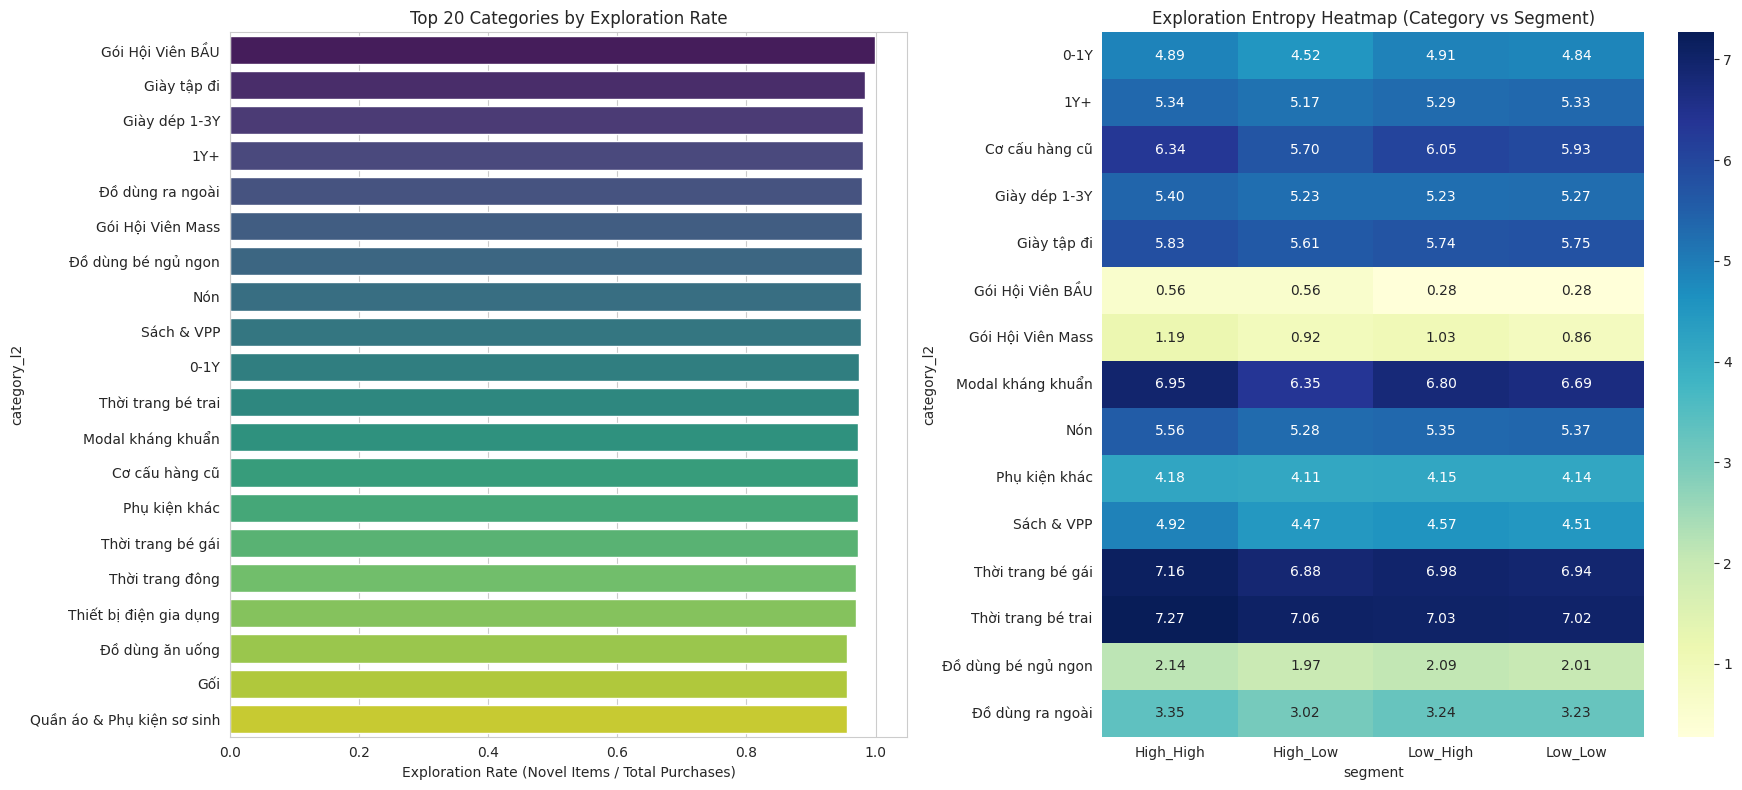

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 1. Bar chart of Category Exploration Rate
sns.barplot(data=cat_exploration.to_pandas().head(20), x='exploration_rate', y='category_l2', palette='viridis', ax=ax1)
ax1.set_title('Top 20 Categories by Exploration Rate')
ax1.set_xlabel('Exploration Rate (Novel Items / Total Purchases)')

# 2. Heatmap of Entropy (Top 15 categories)
top_20_cats = cat_exploration.head(15)['category_l2'].to_list()
pivot_entropy = (
    entropy_df
    .filter(pl.col('category_l2').is_in(top_20_cats))
    .to_pandas()
    .pivot(index='category_l2', columns='segment', values='entropy')
)
sns.heatmap(pivot_entropy, cmap='YlGnBu', annot=True, fmt='.2f', ax=ax2)
ax2.set_title('Exploration Entropy Heatmap (Category vs Segment)')

plt.tight_layout()
plt.show()

## 6. Conclusion and Decision

**Decision Rule:** Keep if category exploration rates show >25% variance across categories, or if exploration significantly correlates with customer segment behavior.

### Summary of Findings

| Metric | Value |
|--------|-------|
| Max Exploration Rate | 99.9% (Membership/Gear) |
| Min Exploration Rate | 28.8% (Bubs/Aptamil Milk) |
| Max Exploration Entropy | 7.27 (Fashion) |
| Variance in Exploration Rate | >70% |

### Interpretation

1. **Habit vs. Novelty:** There is a structural difference in how customers shop across categories. Consumables (Milk) are highly habitual, while Gear/Fashion are highly exploratory.
2. **Segment Consistency:** High-value customers drive discovery in high-entropy categories like Fashion.

### Actionable Insight

**Ranking Logic:** Implement a **'Novelty Temperature'** parameter per category. 
- For **Habitual Categories** (Milk, Diapers): Set Temperature to Low. Prioritize **'Buy Again'** and **'Frequently Bought'** signals. Use a negative boost for items the customer hasn't bought before unless they are explicitly searching.
- For **Exploratory Categories** (Apparel, Toys, Gear): Set Temperature to High. Prioritize **'New Arrivals'**, **'Trending'**, and **'Diversification'** (don't show the same brand/style twice). Filter out items the customer already owns to maximize 'Discovery'.

**Final verdict:** **KEEP**